# Explore here

In [1]:
# Your code here
# Recopilacion y planteamiento del probelma
import pandas as pd

df = pd.read_csv('https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv',sep = ';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


# OBJETIVO
Crear un modelo predecir si un cliente contratará o no un depósito a largo plazo.

In [2]:
# Exploracion y limpieza de datos
df.shape

(41188, 21)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

1. no hay datos nulos
2. 11 Columnas son str
3. 10 Columnas son numericas

In [4]:
# Eliminar duplicados
df.duplicated().sum()

np.int64(12)

In [5]:
# ELiminamos las 12 filas duplicadas detectadas.
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [6]:
# Elimino informacion irrelevante
df = df.drop(['contact','day_of_week','duration','campaign','pdays'],axis=1)
df.head()

,age,job,marital,education,default,housing,loan,month,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,may,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,may,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,may,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,may,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,may,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# ANALISIS UNIVARIANTE

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  str    
 2   marital         41176 non-null  str    
 3   education       41176 non-null  str    
 4   default         41176 non-null  str    
 5   housing         41176 non-null  str    
 6   loan            41176 non-null  str    
 7   month           41176 non-null  str    
 8   previous        41176 non-null  int64  
 9   poutcome        41176 non-null  str    
 10  emp.var.rate    41176 non-null  float64
 11  cons.price.idx  41176 non-null  float64
 12  cons.conf.idx   41176 non-null  float64
 13  euribor3m       41176 non-null  float64
 14  nr.employed     41176 non-null  float64
 15  y               41176 non-null  str    
dtypes: float64(5), int64(2), str(9)
memory usage: 5.3 MB


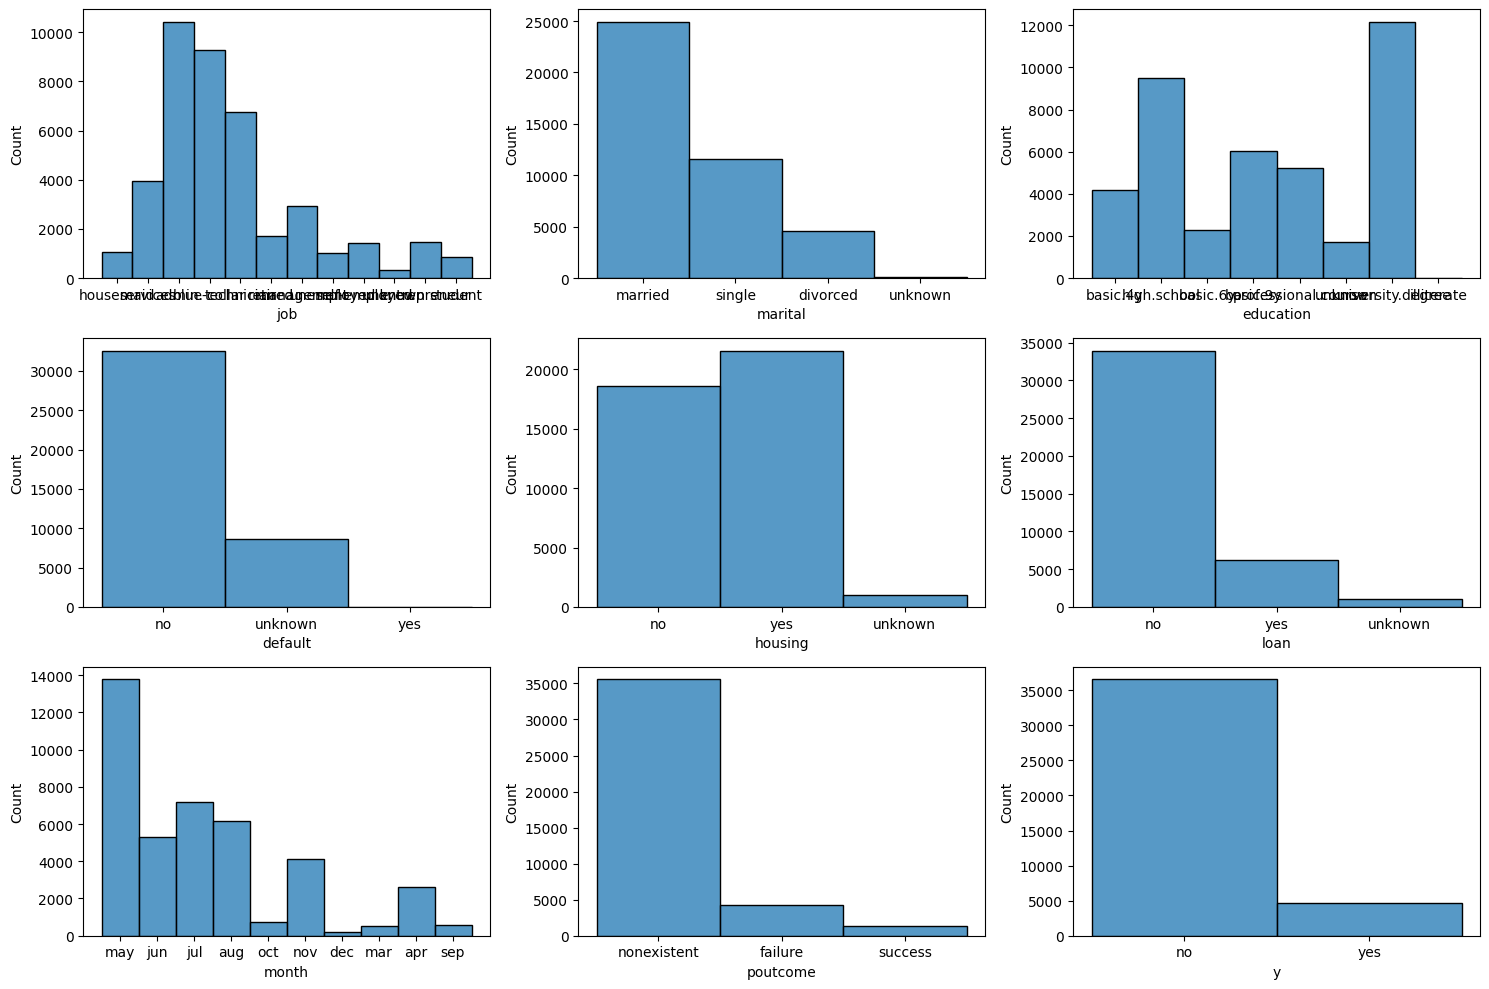

In [8]:
# Variables Categoricas
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(3,3, figsize=(15,10))

sns.histplot(ax = axis[0,0], data = df, x = 'job')
sns.histplot(ax = axis[0,1], data = df, x = 'marital')
sns.histplot(ax = axis[0,2], data = df, x = 'education')
sns.histplot(ax = axis[1,0], data = df, x = 'default')
sns.histplot(ax = axis[1,1], data = df, x = 'housing')
sns.histplot(ax = axis[1,2], data = df, x = 'loan')
sns.histplot(ax = axis[2,0], data = df, x = 'month')
sns.histplot(ax = axis[2,1], data = df, x = 'poutcome')
sns.histplot(ax = axis[2,2], data = df, x = 'y')

plt.tight_layout()
plt.show()

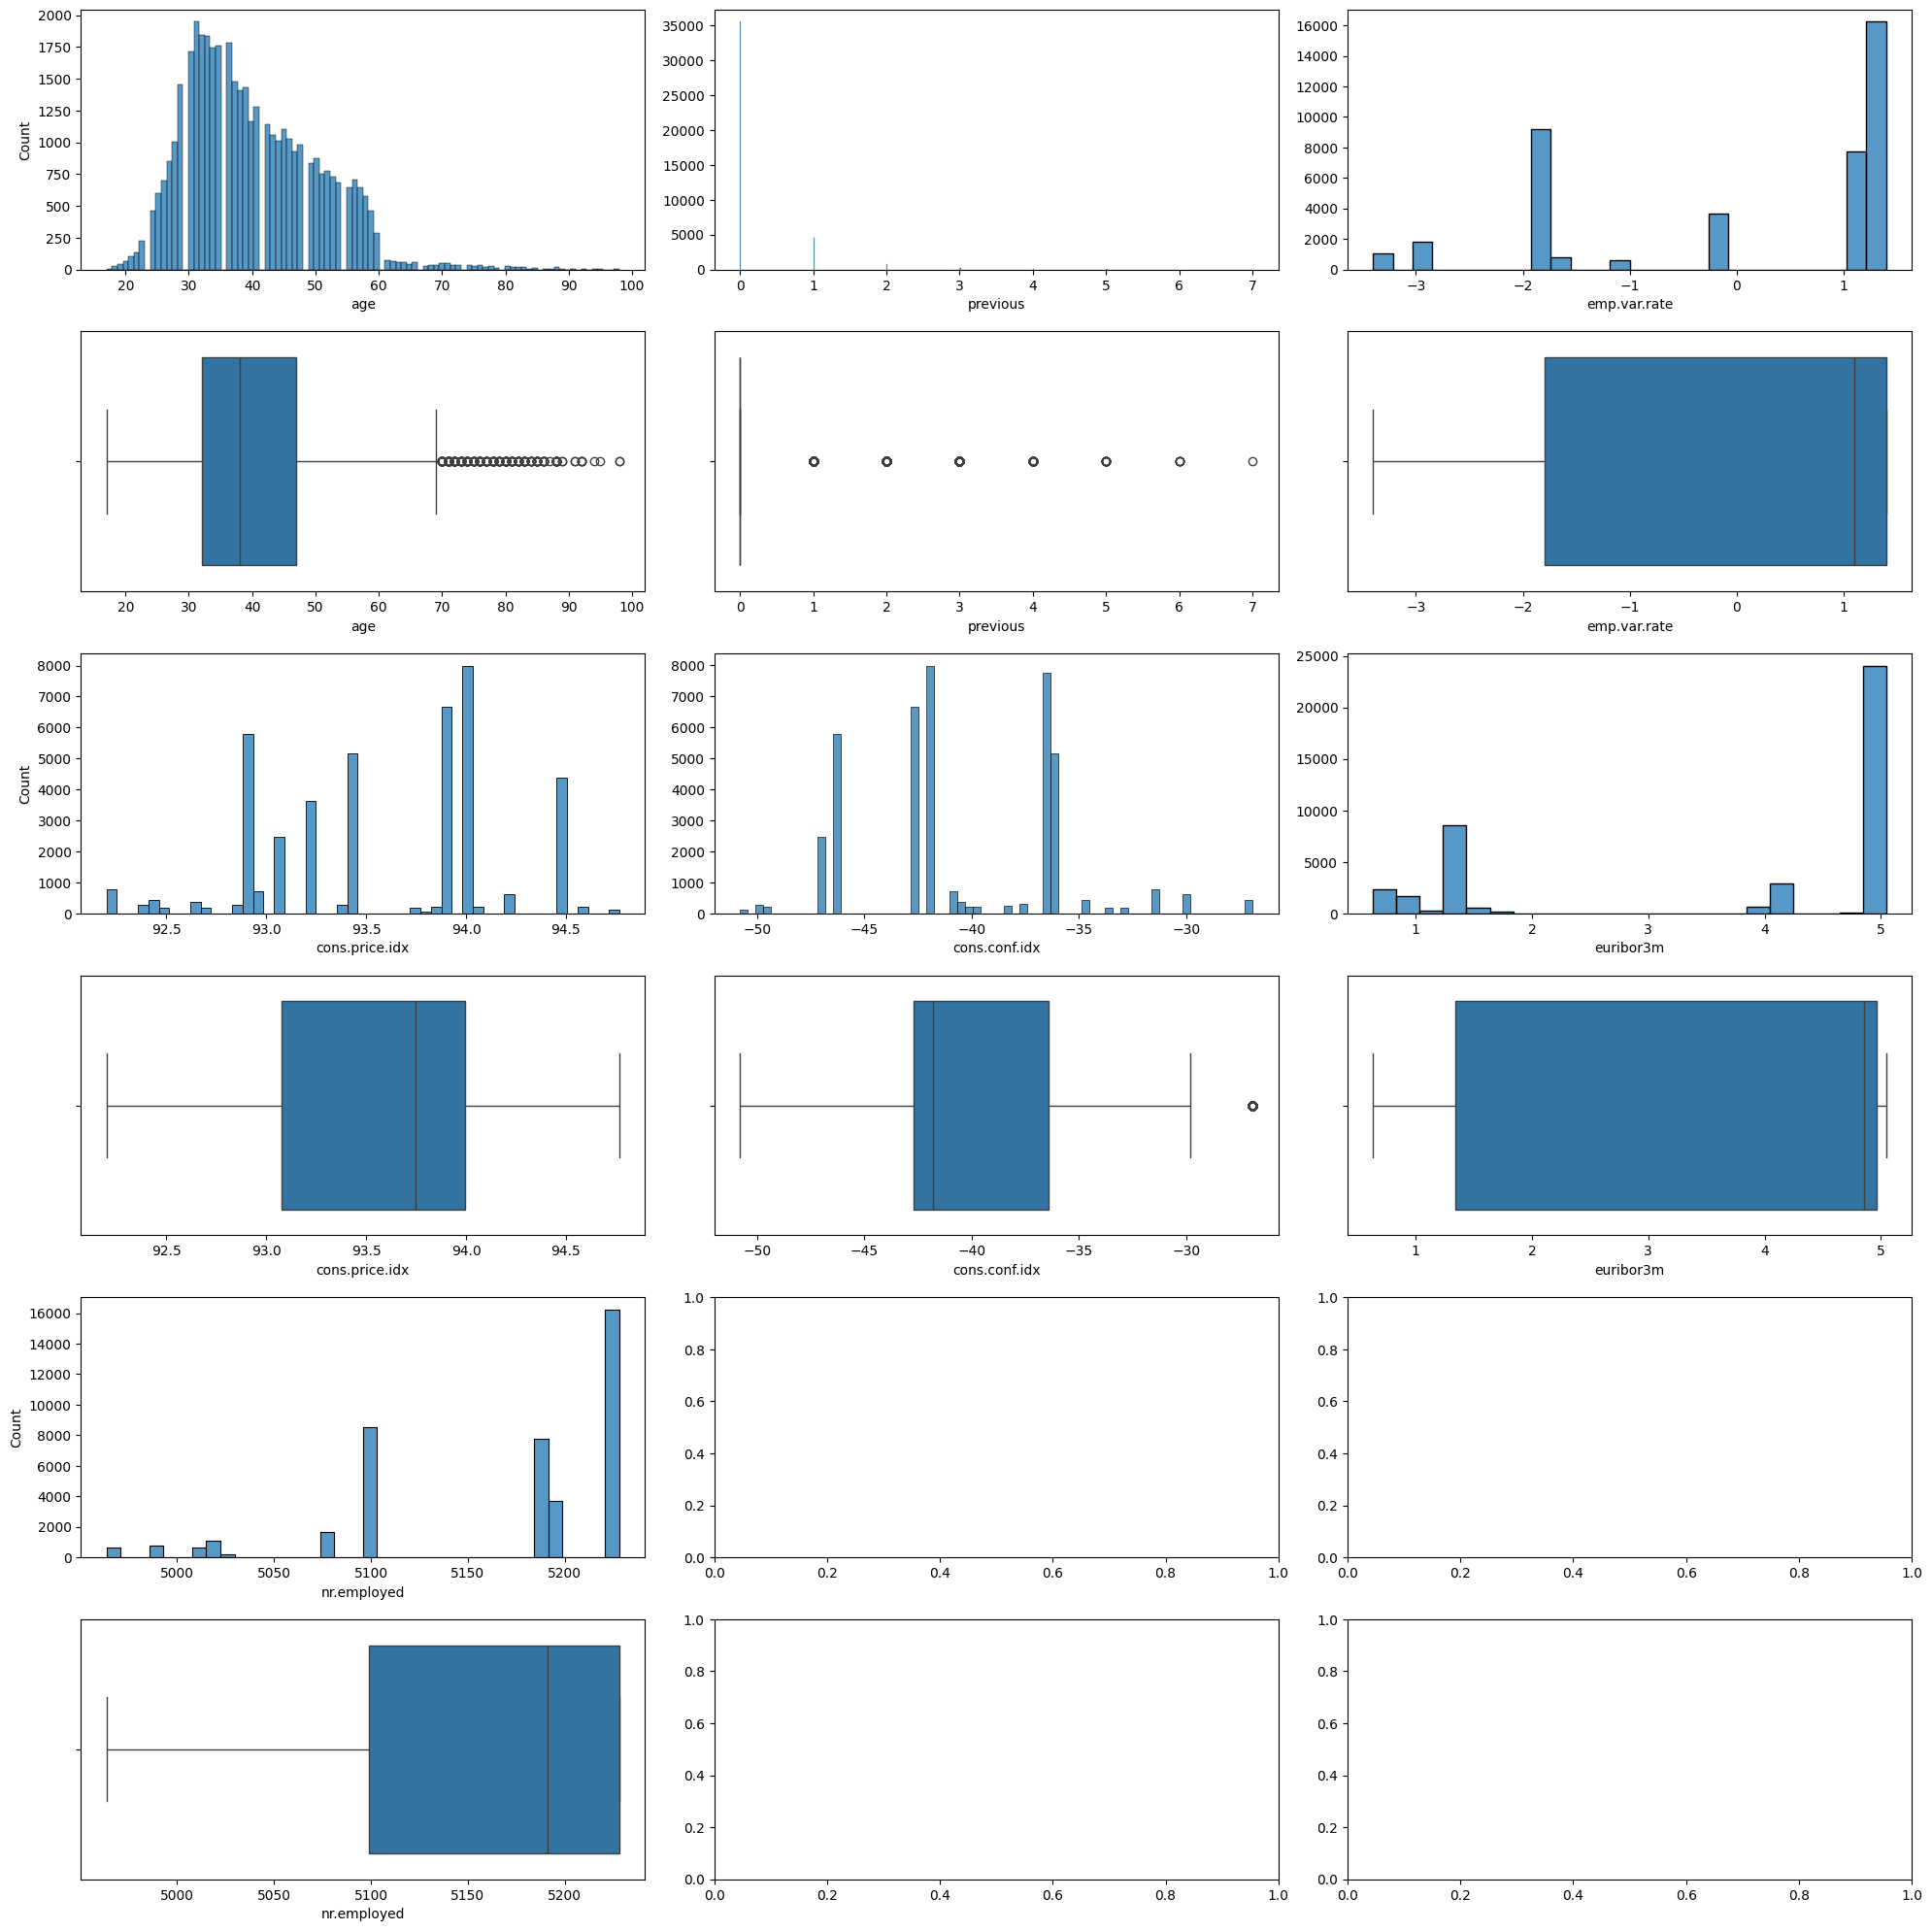

In [9]:
# Variables Numericas

fig, axis = plt.subplots(6,3,figsize=(20,20))

sns.histplot(ax = axis[0,0], data = df, x = 'age')
sns.boxplot (ax = axis[1,0], data = df, x = 'age')
sns.histplot(ax = axis[0,1], data = df, x = 'previous').set(ylabel = None)
sns.boxplot (ax = axis[1,1], data = df, x = 'previous')
sns.histplot(ax = axis[0,2], data = df, x = 'emp.var.rate').set(ylabel = None)
sns.boxplot (ax = axis[1,2], data = df, x = 'emp.var.rate')
sns.histplot(ax = axis[2,0], data = df, x = 'cons.price.idx')
sns.boxplot (ax = axis[3,0], data = df, x = 'cons.price.idx')
sns.histplot(ax = axis[2,1], data = df, x = 'cons.conf.idx').set(ylabel = None)
sns.boxplot (ax = axis[3,1], data = df, x = 'cons.conf.idx')
sns.histplot(ax = axis[2,2], data = df, x = 'euribor3m').set(ylabel = None)
sns.boxplot (ax = axis[3,2], data = df, x = 'euribor3m')
sns.histplot(ax = axis[4,0], data = df, x = 'nr.employed')
sns.boxplot (ax = axis[5,0], data = df, x = 'nr.employed')

plt.tight_layout()
plt.show()



# ANALISIS MULTIVARIANTE

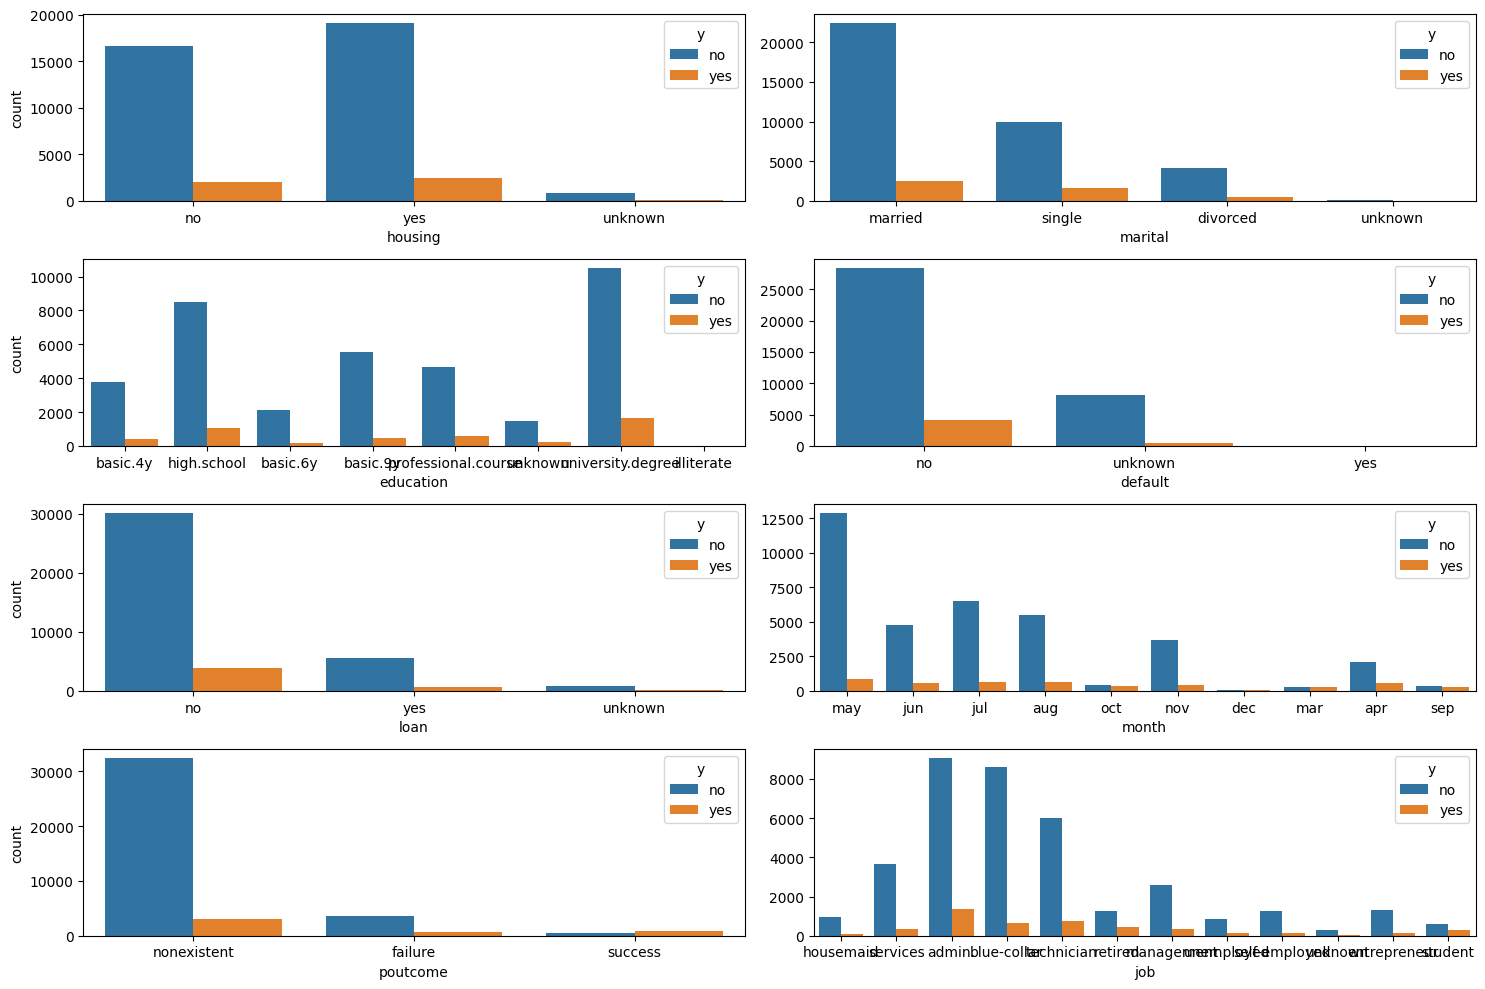

In [10]:
# Analisis Categorico-Categorico

fig, axis = plt.subplots(4,2,figsize = (15,10))

sns.countplot(ax = axis[0,0], data= df, x = 'housing', hue = 'y')
sns.countplot(ax = axis[0,1], data= df, x = 'marital', hue = 'y').set(ylabel = None)
sns.countplot(ax = axis[1,0], data= df, x = 'education', hue = 'y')
sns.countplot(ax = axis[1,1], data= df, x = 'default', hue = 'y').set(ylabel = None)
sns.countplot(ax = axis[2,0], data= df, x = 'loan', hue = 'y')
sns.countplot(ax = axis[2,1], data= df, x = 'month', hue = 'y').set(ylabel = None)
sns.countplot(ax = axis[3,0], data= df, x = 'poutcome', hue = 'y')
sns.countplot(ax = axis[3,1], data= df, x = 'job', hue = 'y').set(ylabel = None)

plt.tight_layout()
plt.show()


In [11]:
# Factorizo las variables categoricas para generar un heatmap

df['job'] = pd.factorize(df['job'])[0]
df['marital'] = pd.factorize(df['marital'])[0]
df['education'] = pd.factorize(df['education'])[0]
df['default'] = pd.factorize(df['default'])[0]
df['housing'] = pd.factorize(df['housing'])[0]
df['loan'] = pd.factorize(df['loan'])[0]
df['month'] = pd.factorize(df['month'])[0]
df['poutcome'] = pd.factorize(df['poutcome'])[0]
df['y'] = pd.factorize(df['y'])[0]

df.head()

,age,job,marital,education,default,housing,loan,month,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,0,0,0,0,0,0,0,0,0,1.1,93.994,-36.4,4.857,5191.0,0
1,57,1,0,1,1,0,0,0,0,0,1.1,93.994,-36.4,4.857,5191.0,0
2,37,1,0,1,0,1,0,0,0,0,1.1,93.994,-36.4,4.857,5191.0,0
3,40,2,0,2,0,0,0,0,0,0,1.1,93.994,-36.4,4.857,5191.0,0
4,56,1,0,1,0,0,1,0,0,0,1.1,93.994,-36.4,4.857,5191.0,0


<Axes: >

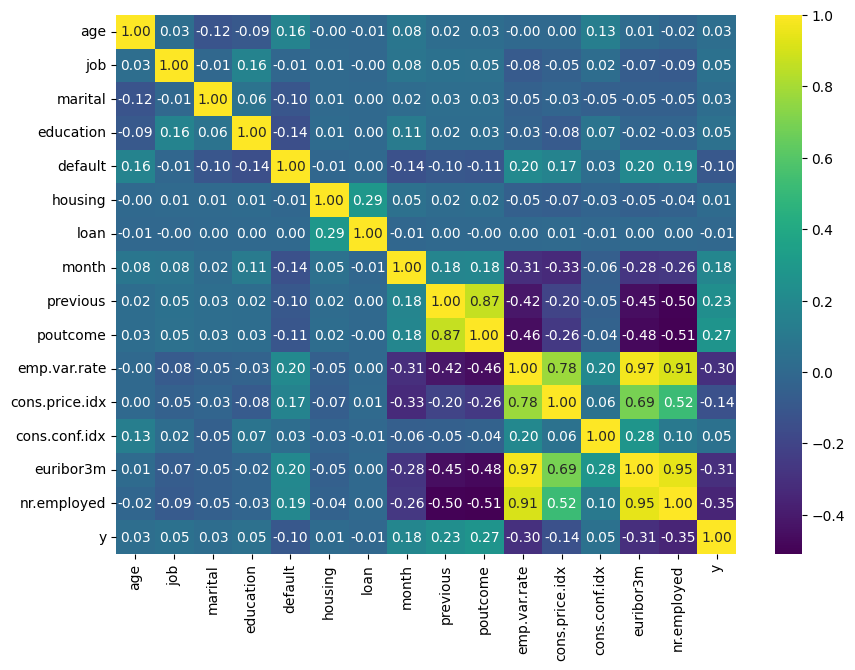

In [12]:
fig, axis = plt.subplots(figsize=(10,7))
sns.heatmap(df.corr(method='pearson'),annot = True,fmt = '.2f',cmap = 'viridis',ax=axis)


Se puede observar que las 3 mejores variables con respecto a mi variable objetivo son: month, previous y poutcome

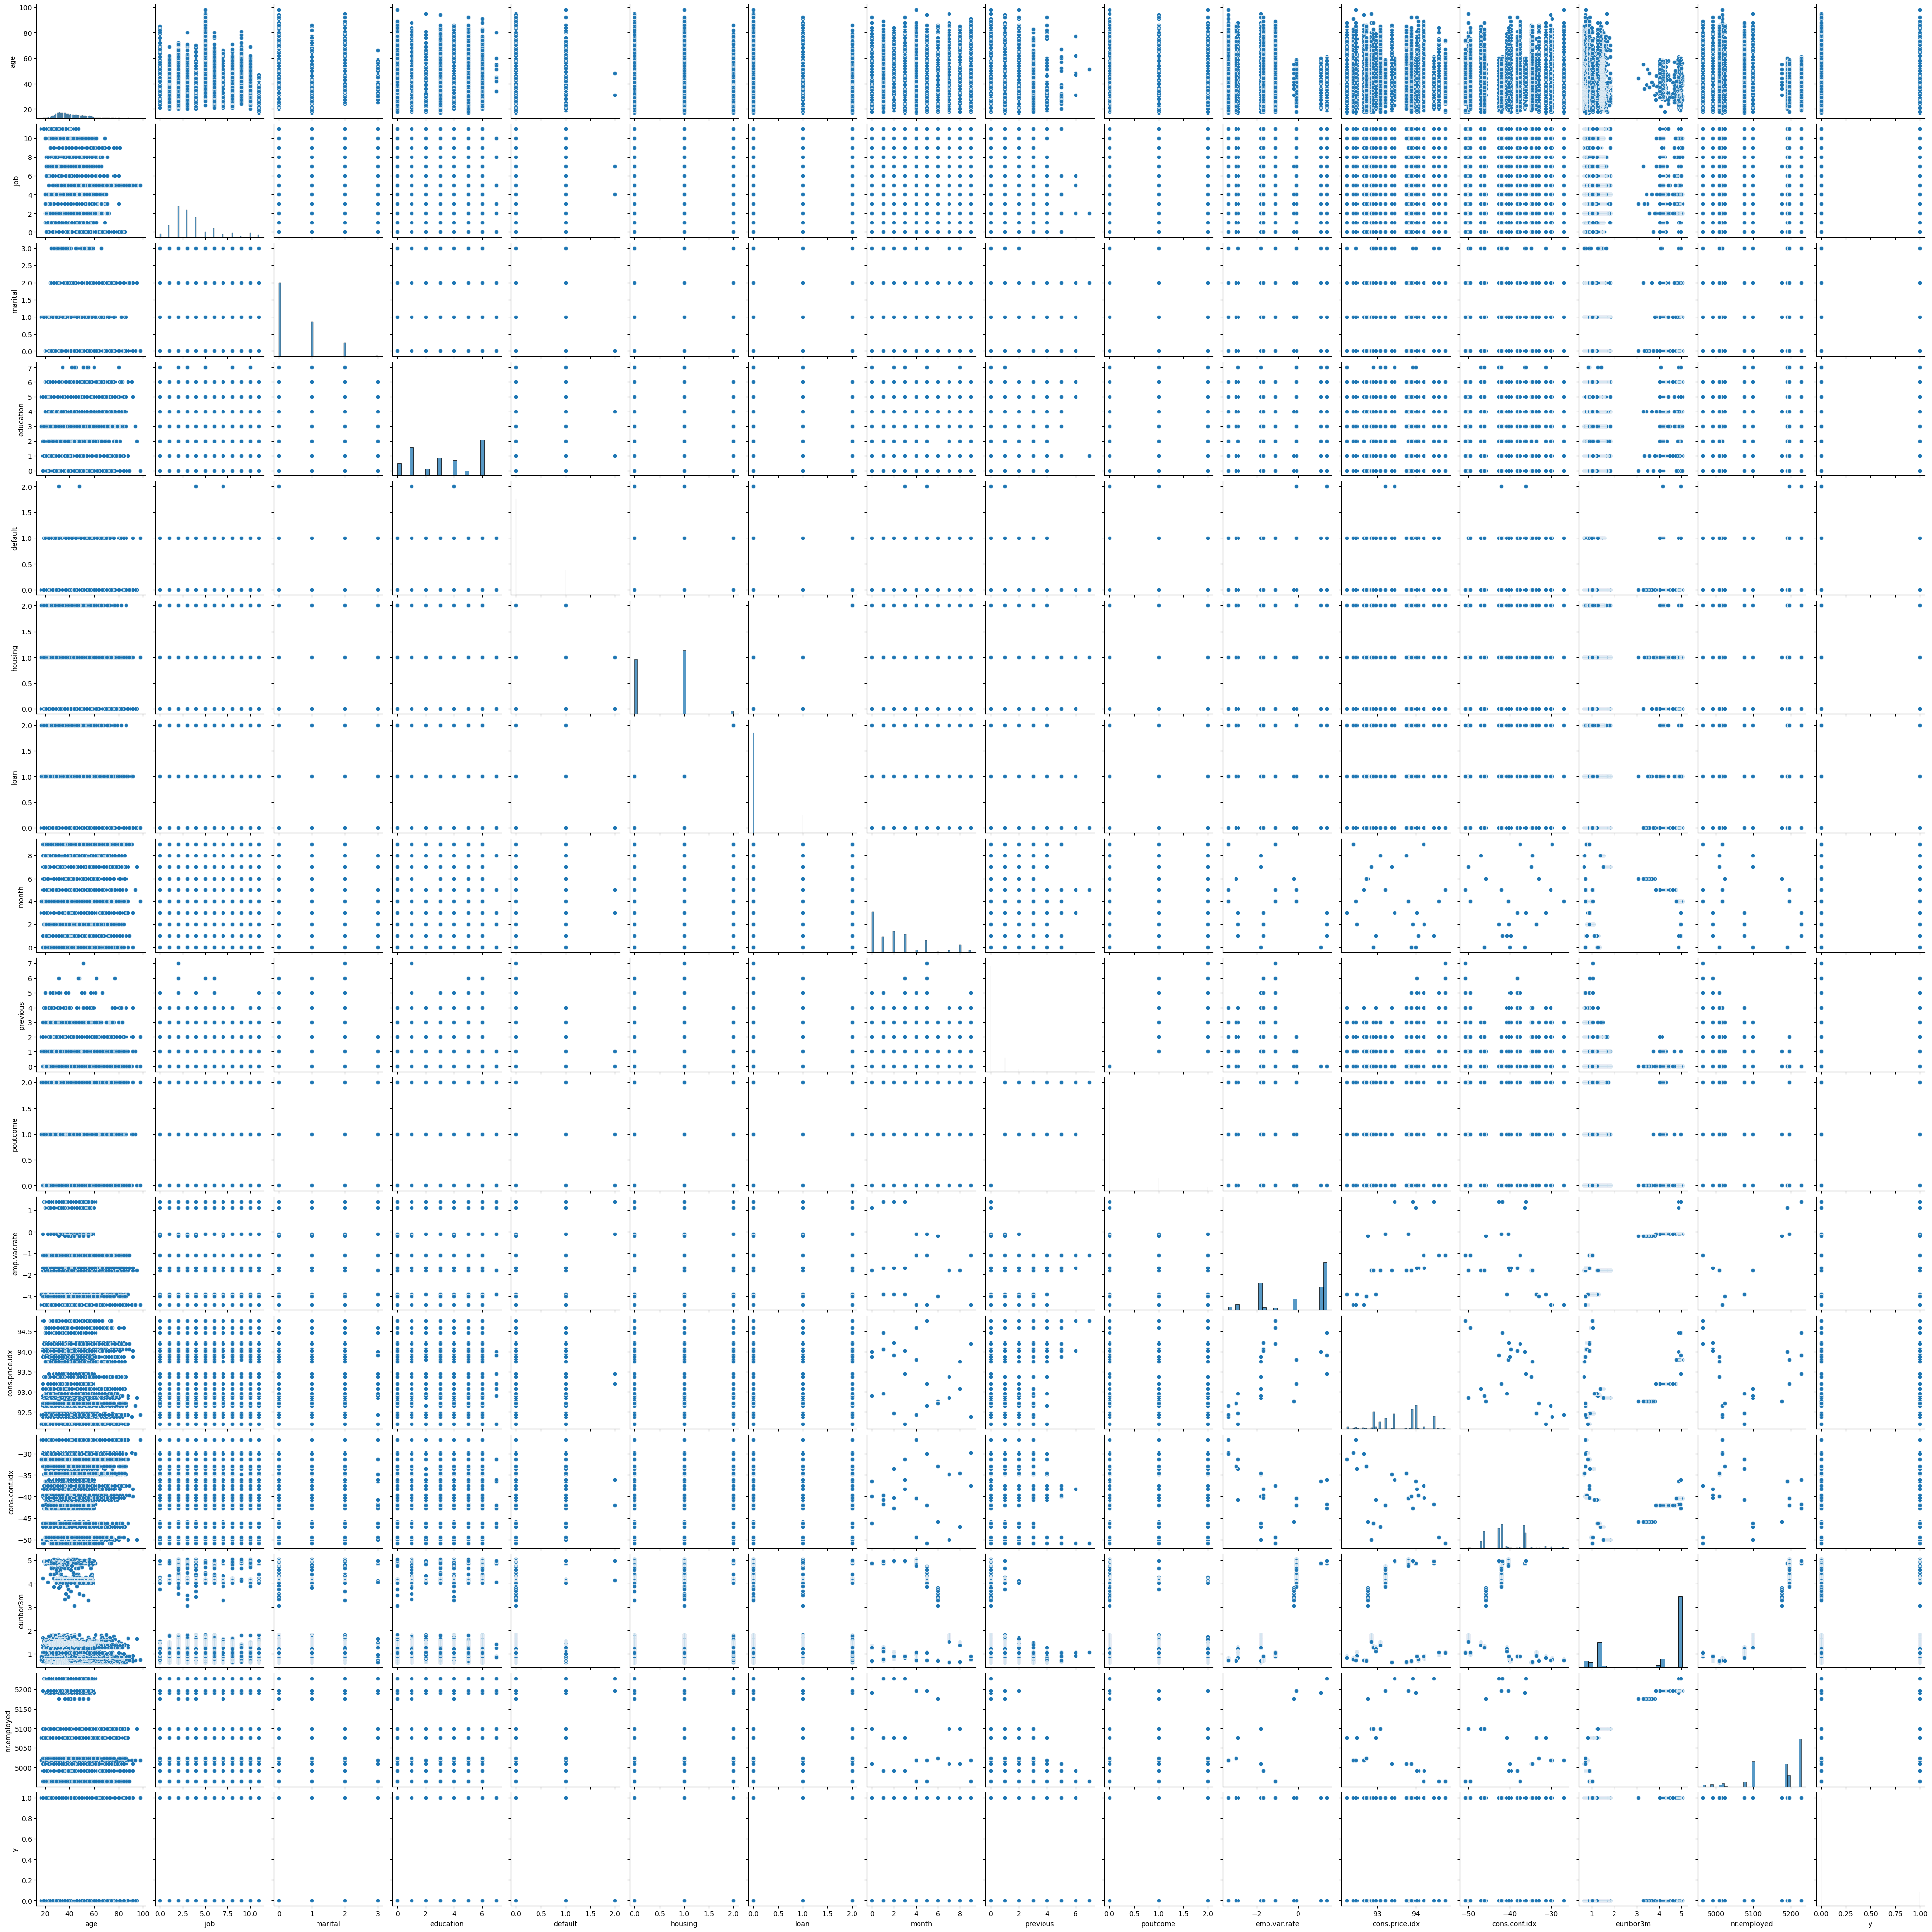

In [13]:
sns.pairplot(data=df)

# INGENIERIA DE CARACTERISTICAS

In [14]:
# Analisis de Outliers

df.describe()

,age,job,marital,education,default,housing,loan,month,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,3.673863,0.510637,3.277370,0.208908,0.571959,0.199825,2.249951,0.173013,0.169953,0.081922,93.575720,-40.502863,3.621293,5167.034870,0.112663
std,10.42068,2.454340,0.696794,2.185558,0.406713,0.541216,0.456055,2.429157,0.494964,0.455811,1.570883,0.578839,4.627860,1.734437,72.251364,0.316184
min,17.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,3.000000,0.000000,3.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,4.000000,1.000000,6.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,11.000000,3.000000,7.000000,2.000000,2.000000,2.000000,9.000000,7.000000,2.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


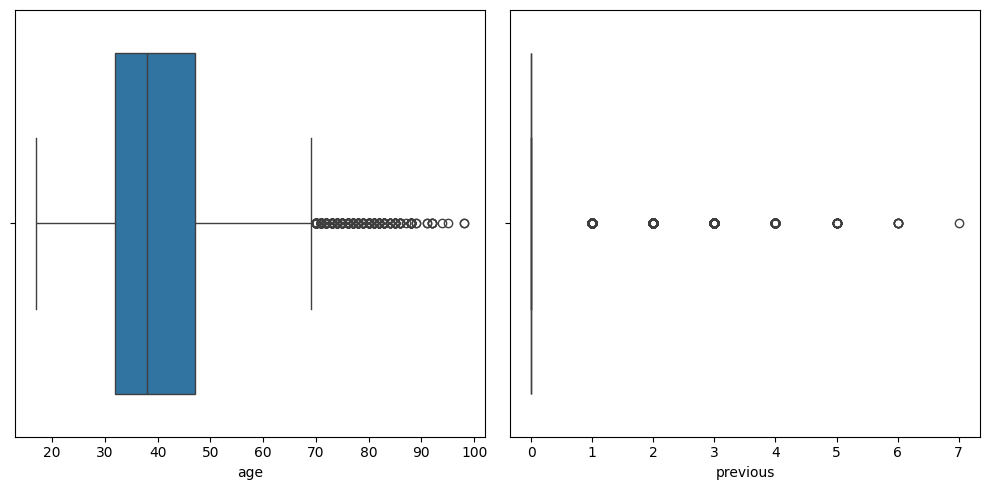

In [15]:
fig, axis = plt.subplots(1,2,figsize=(10,5))


sns.boxplot (ax = axis[0], data = df, x = 'age')
sns.boxplot (ax = axis[1], data = df, x = 'previous')

plt.tight_layout()
plt.show()

In [16]:
df[df['previous']>1]

,age,job,marital,education,default,housing,loan,month,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
25996,35,6,0,6,0,1,1,5,2,2,-0.1,93.200,-42.0,4.120,5195.8,0
27658,50,2,2,6,0,1,0,5,2,2,-0.1,93.200,-42.0,4.021,5195.8,0
27778,38,4,0,6,0,0,0,7,2,1,-1.8,92.843,-50.0,1.687,5099.1,1
27832,30,11,1,1,0,0,0,7,2,1,-1.8,92.843,-50.0,1.640,5099.1,1
27991,29,2,1,6,0,1,0,8,2,2,-1.8,93.075,-47.1,1.498,5099.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41170,40,6,2,6,0,1,0,5,4,1,-1.1,94.767,-50.8,1.030,4963.6,0
41173,62,5,0,6,0,1,0,5,2,1,-1.1,94.767,-50.8,1.031,4963.6,1
41174,62,5,0,6,0,1,0,5,6,2,-1.1,94.767,-50.8,1.031,4963.6,1
41175,34,11,1,5,0,1,0,5,2,1,-1.1,94.767,-50.8,1.031,4963.6,0


Hay mil valores de previous mayores a 1, es una minoria respecto a 41 mil datos. No pareciera ser un error de tipeo.

In [17]:
# analisis de age
df['age'].describe()

count    41176.00000
mean        40.02380
std         10.42068
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

In [18]:
df[df['age']>90]

,age,job,marital,education,default,housing,loan,month,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
27826,95,5,2,2,0,0,0,7,0,0,-1.8,92.843,-50.0,1.650,5099.1,0
38022,91,5,0,6,0,1,1,9,2,1,-3.4,92.379,-29.8,0.781,5017.5,0
38032,91,5,0,6,0,0,1,9,0,0,-3.4,92.379,-29.8,0.781,5017.5,0
38452,98,5,0,0,1,1,0,4,2,2,-3.4,92.431,-26.9,0.730,5017.5,1
38455,98,5,0,0,1,1,0,4,0,0,-3.4,92.431,-26.9,0.730,5017.5,1
38921,94,5,0,3,0,0,0,5,1,1,-3.4,92.649,-30.1,0.716,5017.5,0
39655,92,5,0,5,0,1,0,0,2,2,-1.8,93.876,-40.0,0.683,5008.7,0
39734,92,5,2,5,1,0,0,0,1,1,-1.8,93.876,-40.0,0.697,5008.7,1
40450,92,5,0,5,0,0,1,3,1,2,-1.7,94.027,-38.3,0.904,4991.6,1
40469,92,5,0,5,0,0,1,3,4,2,-1.7,94.027,-38.3,0.903,4991.6,1


Hay personas mayores de 80 que han aceptado los depositos a largo plazo. En este caso forman parte de las personas que aceptaron, no se eliminar los datos

In [19]:
# Analisis de valores faltantes

df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
month             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [20]:
# Escalado de valores
# No muestran una distribucion normal. Utilizare MinMaxEscaler
from sklearn.preprocessing import MinMaxScaler
x = df.drop(['y'],axis=1)

variables = ['age',]
scaler_minmax = MinMaxScaler()
x_minmax = pd.DataFrame(scaler_minmax.fit_transform(x), index = df.index, columns= x.columns)

x_minmax.head()

,age,job,marital,education,default,housing,loan,month,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,0.481481,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735
1,0.493827,0.090909,0.0,0.142857,0.5,0.0,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735
2,0.246914,0.090909,0.0,0.142857,0.0,0.5,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735
3,0.283951,0.181818,0.0,0.285714,0.0,0.0,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735
4,0.481481,0.090909,0.0,0.142857,0.0,0.0,0.5,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735


In [21]:
x_minmax['y'] = df['y']

x_minmax.head()

,age,job,marital,education,default,housing,loan,month,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,0.481481,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0
1,0.493827,0.090909,0.0,0.142857,0.5,0.0,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0
2,0.246914,0.090909,0.0,0.142857,0.0,0.5,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0
3,0.283951,0.181818,0.0,0.285714,0.0,0.0,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0
4,0.481481,0.090909,0.0,0.142857,0.0,0.0,0.5,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0


In [22]:
# Seleccion de Datos

from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split

x = x_minmax.drop('y', axis = 1)
y = x_minmax['y']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

modelo_sel = SelectKBest(chi2, k =7)
modelo_sel.fit(x_train,y_train)
ix = modelo_sel.get_support()

x_train_sel = pd.DataFrame(modelo_sel.transform(x_train), columns = x_train.columns.values[ix])
x_test_sel = pd.DataFrame(modelo_sel.transform(x_test), columns = x_test.columns.values[ix])


# INICIACION DEL MODELO

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train_sel,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
# predecimos
y_pred = model.predict(x_test_sel)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(8236,))

In [25]:
# Evaluamos la eficiencia del modelo

from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.8879310344827587

# Mejora del Modelo

In [26]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

hyperparametros = {
    'C': np.logspace(-4,4,20),
    'solver': ['newton-cg', 'lbfgs','liblinear','sag','saga']
}

random_search = RandomizedSearchCV(model, hyperparametros, n_iter=100, scoring='accuracy', cv = 5, random_state=42)
random_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'solver': ['newton-cg', 'lbfgs', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed

In [27]:
random_search.fit(x_train_sel, y_train)
print(f'Los mejores hiperparametros son:{random_search.best_params_}')

Los mejores hiperparametros son:{'solver': 'lbfgs', 'C': np.float64(0.08858667904100823)}


In [31]:
model_random_search = LogisticRegression(C = 0.08858667904100823 ,solver= 'lbfgs')
model_random_search.fit(x_train_sel, y_train)
y_pred2 = model_random_search.predict(x_test_sel)

random_search_accurary = accuracy_score(y_test,y_pred2)
random_search_accurary

0.889752306945119

In [39]:
mejora = abs(0.8879310344827587-0.889752306945119)/0.889752306945119*100

print( f'la mejora del modelo fue de: {round(mejora,3)}%')


la mejora del modelo fue de: 0.205%
